<a href="https://colab.research.google.com/github/njwbilll/Tugas-4_Practical-Statistics-for-Data-Scientists-O-Reilly_Najwa-Bilqis-Al-Khalidah/blob/main/03_Statistical_Experiments_and_Significance_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3: Statistical Experiments and Significance Testing

**Referensi:** Practical Statistics for Data Scientists (Peter Bruce, Andrew Bruce, Peter Gedeck)

***

## Ringkasan Chapter

Desain eksperimen adalah fondasi utama dalam praktik statistik untuk memastikan bahwa kesimpulan yang diambil didasarkan pada bukti yang solid dan bukan kebetulan semata. Bab ini membahas bagaimana kita merancang eksperimen (seperti A/B Testing), merumuskan hipotesis, dan menggunakan metode komputasi modern (seperti resampling) serta pengujian statistik tradisional (seperti t-Test dan ANOVA) untuk mengevaluasi signifikansi sebuah temuan.

Fokus utama dari pendekatan modern dalam bab ini adalah penggunaan simulasi dan permutasi, yang lebih intuitif dan seringkali lebih tangguh dibandingkan mengandalkan formula matematika klasik yang memiliki banyak asumsi kaku.

### Topik yang Dibahas:
1. A/B Testing dan Pengujian Hipotesis
2. Permutation Tests (Resampling)
3. Statistical Significance dan P-Values
4. T-Tests
5. Multiple Groups: ANOVA (Analysis of Variance)
6. Chi-Square Test


***
## Setup: Import Library

Kita menginisialisasi environment dengan mengimpor modul standar untuk manipulasi matriks, visualisasi, dan modul uji statistik dari Scipy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import random
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil dimuat.")


Library berhasil dimuat.


***
## 1. A/B Testing dan Pengujian Hipotesis

### Penjelasan Teori

A/B Testing adalah eksperimen standar yang membandingkan dua kelompok untuk menentukan perawatan (treatment) mana yang memberikan hasil lebih superior. Kelompok A biasanya bertindak sebagai kontrol (desain saat ini), dan Kelompok B bertindak sebagai kelompok perlakuan (desain baru).

Dalam pengujian hipotesis, kita selalu memulai dengan **Null Hypothesis (H0)** yang mengasumsikan bahwa tidak ada perbedaan nyata antara Kelompok A dan Kelompok B. Perbedaan yang terlihat hanyalah akibat variasi acak. Sebaliknya, **Alternative Hypothesis (H1)** menyatakan bahwa ada perbedaan nyata dan perlakuan memberikan efek yang signifikan.

Mari kita buat dataset simulasi metrik konversi e-commerce, di mana kita ingin menguji apakah tata letak halaman web baru meningkatkan jumlah waktu yang dihabiskan pengguna (dalam detik).

Rata-rata Waktu Kontrol: 120.21 detik
Rata-rata Waktu Perlakuan: 125.95 detik
Perbedaan Terobservasi: 5.75 detik


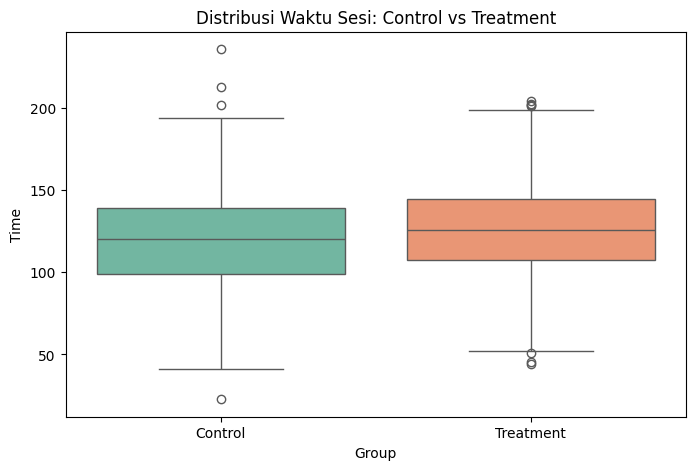

In [2]:
# Simulasi data waktu sesi pengguna (dalam detik)
np.random.seed(42)
waktu_kontrol = np.random.normal(loc=120, scale=30, size=500) # Halaman lama
waktu_perlakuan = np.random.normal(loc=125, scale=30, size=500) # Halaman baru

df_ab = pd.DataFrame({
    'Group': ['Control'] * 500 + ['Treatment'] * 500,
    'Time': np.concatenate([waktu_kontrol, waktu_perlakuan])
})

mean_kontrol = df_ab[df_ab['Group'] == 'Control']['Time'].mean()
mean_perlakuan = df_ab[df_ab['Group'] == 'Treatment']['Time'].mean()
perbedaan_observasi = mean_perlakuan - mean_kontrol

print(f"Rata-rata Waktu Kontrol: {mean_kontrol:.2f} detik")
print(f"Rata-rata Waktu Perlakuan: {mean_perlakuan:.2f} detik")
print(f"Perbedaan Terobservasi: {perbedaan_observasi:.2f} detik")

plt.figure(figsize=(8, 5))
sns.boxplot(x='Group', y='Time', data=df_ab, palette='Set2')
plt.title('Distribusi Waktu Sesi: Control vs Treatment')
plt.show()


***
## 2. Permutation Tests (Resampling)

### Penjelasan Teori

Kita melihat ada perbedaan antara dua grup. Pertanyaannya, apakah perbedaan ini secara statistik signifikan, atau hanya efek dari pengambilan sampel acak?

Uji permutasi adalah cara untuk mengevaluasi Null Hypothesis dengan mengacak (shuffle) label data dari kedua kelompok secara bersama-sama. Logikanya: Jika tata letak halaman web benar-benar tidak memberikan pengaruh (H0 benar), maka menukar label Control dan Treatment secara acak ke data waktu yang ada tidak akan mengubah distribusi hasil. Kita melakukan pengacakan ini ribuan kali untuk membangun distribusi perbedaan di bawah asumsi H0.

In [3]:
def permutation_test(data, col_value, col_group, n_permutations=1000):
    # Mengambil nilai grup asli
    n_control = len(data[data[col_group] == 'Control'])
    values = data[col_value].values

    perbedaan_acak = []

    for _ in range(n_permutations):
        # Mengacak seluruh nilai (shuffling)
        np.random.shuffle(values)

        # Membagi kembali secara palsu
        grup_a_palsu = values[:n_control]
        grup_b_palsu = values[n_control:]

        # Menghitung perbedaan rata-rata simulasi
        diff = grup_b_palsu.mean() - grup_a_palsu.mean()
        perbedaan_acak.append(diff)

    return np.array(perbedaan_acak)

distribusi_null = permutation_test(df_ab.copy(), 'Time', 'Group', n_permutations=2000)

print("Distribusi null menggunakan uji permutasi berhasil dikalkulasi.")


Distribusi null menggunakan uji permutasi berhasil dikalkulasi.


***
## 3. Statistical Significance dan P-Values

### Penjelasan Teori

P-Value (Nilai-P) adalah probabilitas untuk mendapatkan hasil setidaknya se-ekstrim hasil observasi kita, dengan asumsi bahwa Null Hypothesis benar. Jika P-Value sangat kecil (biasanya di bawah alpha 0.05), kita menganggap peristiwa tersebut sangat langka terjadi secara kebetulan, sehingga kita menolak Null Hypothesis.

Kita dapat menghitung P-Value secara empiris dari distribusi permutasi yang telah kita buat pada langkah sebelumnya dengan membandingkan seberapa banyak nilai acak yang melebihi perbedaan asli yang kita amati.

Nilai P-Value Empiris: 0.0010


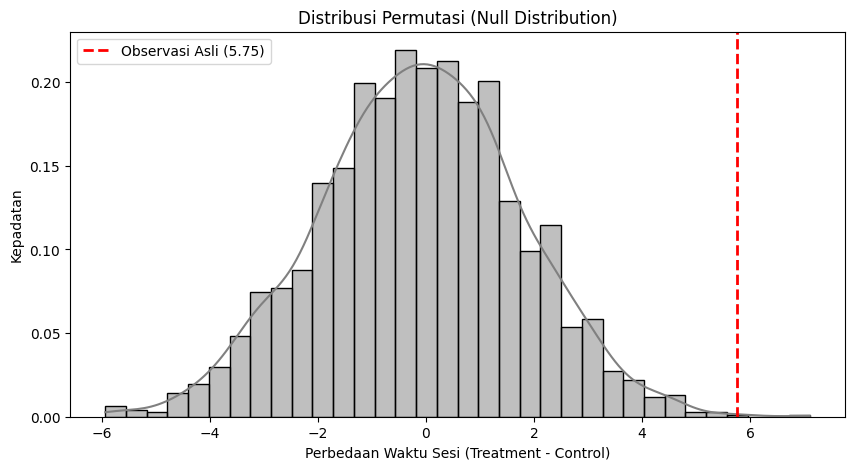

In [4]:
# Menghitung P-Value empiris
# Berapa persen perbedaan dari simulasi permutasi yang lebih besar atau sama dengan observasi asli?
p_value_empiris = np.mean(distribusi_null >= perbedaan_observasi)

print(f"Nilai P-Value Empiris: {p_value_empiris:.4f}")

plt.figure(figsize=(10, 5))
sns.histplot(distribusi_null, kde=True, color='gray', stat='density')
plt.axvline(perbedaan_observasi, color='red', linestyle='dashed', linewidth=2,
            label=f'Observasi Asli ({perbedaan_observasi:.2f})')
plt.title('Distribusi Permutasi (Null Distribution)')
plt.xlabel('Perbedaan Waktu Sesi (Treatment - Control)')
plt.ylabel('Kepadatan')
plt.legend()
plt.show()


***
## 4. T-Tests (Pengujian Parametrik Klasik)

### Penjelasan Teori

Sebelum komputer memiliki daya komputasi tinggi untuk melakukan simulasi permutasi ribuan kali dalam hitungan detik, para ahli statistik mengandalkan formula matematis untuk memperkirakan distribusi null. T-Test dari Student adalah salah satu uji yang paling populer untuk membandingkan rata-rata dari dua kelompok.

T-Test mengasumsikan bahwa data terdistribusi normal. Meskipun memiliki asumsi ketat, t-Test sangat mudah dipanggil menggunakan pustaka Scipy dan biasanya memberikan hasil p-value yang sejalan dengan pendekatan uji permutasi jika ukuran sampel besar (berkat Central Limit Theorem).

In [5]:
# Menggunakan Two-Sample T-Test dari Scipy
t_stat, p_value_ttest = stats.ttest_ind(
    df_ab[df_ab['Group'] == 'Treatment']['Time'],
    df_ab[df_ab['Group'] == 'Control']['Time'],
    equal_var=False, # Welch's t-test (tidak mengasumsikan varians sama)
    alternative='greater' # Uji satu arah (Apakah treatment > control?)
)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value (T-Test): {p_value_ttest:.4f}")
print("Perhatikan bahwa p-value ini sangat mendekati p-value empiris dari uji permutasi.")


T-Statistic: 3.0934
P-Value (T-Test): 0.0010
Perhatikan bahwa p-value ini sangat mendekati p-value empiris dari uji permutasi.


***
## 5. Multiple Groups: ANOVA (Analysis of Variance)

### Penjelasan Teori

Jika kita memiliki lebih dari dua kelompok untuk dibandingkan (misalnya, kita menguji desain Halaman A, Halaman B, dan Halaman C sekaligus), melakukan beberapa uji t-Test secara berpasangan adalah prosedur yang salah karena akan meningkatkan probabilitas terjadinya error tipe 1 (False Positive).

Solusinya adalah ANOVA (Analysis of Variance). ANOVA mengevaluasi hipotesis nol umum bahwa seluruh rata-rata kelompok adalah identik. ANOVA melakukan ini dengan membandingkan varians di dalam masing-masing kelompok (within-group variance) dengan varians antar kelompok (between-group variance). Metrik uji yang dihasilkan disebut F-Statistic.

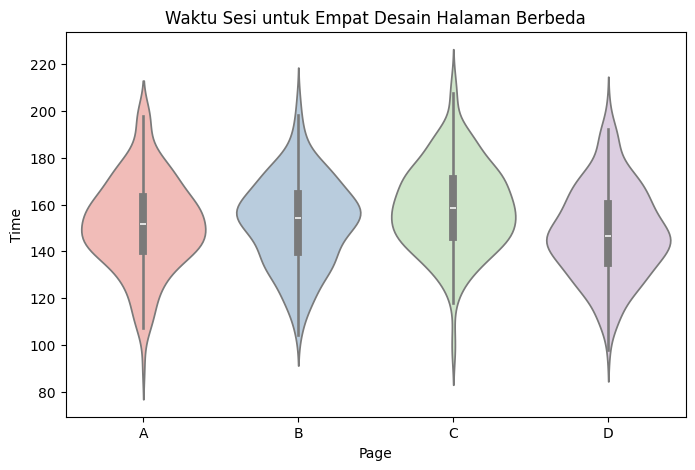

F-Statistic ANOVA: 11.3222
P-Value ANOVA: 2.8073e-07
Kesimpulan: Minimal ada satu desain halaman yang memiliki rata-rata signifikan secara statistik.


In [6]:
# Simulasi data konversi (waktu) untuk 4 halaman web yang berbeda
np.random.seed(10)
page_A = np.random.normal(150, 20, 200)
page_B = np.random.normal(152, 20, 200)
page_C = np.random.normal(160, 20, 200)
page_D = np.random.normal(148, 20, 200)

df_anova = pd.DataFrame({
    'Page': ['A']*200 + ['B']*200 + ['C']*200 + ['D']*200,
    'Time': np.concatenate([page_A, page_B, page_C, page_D])
})

# Visualisasi grup
plt.figure(figsize=(8, 5))
sns.violinplot(x='Page', y='Time', data=df_anova, palette='Pastel1')
plt.title('Waktu Sesi untuk Empat Desain Halaman Berbeda')
plt.show()

# Eksekusi One-Way ANOVA
f_stat, p_value_anova = stats.f_oneway(page_A, page_B, page_C, page_D)

print(f"F-Statistic ANOVA: {f_stat:.4f}")
print(f"P-Value ANOVA: {p_value_anova:.4e}")
if p_value_anova < 0.05:
    print("Kesimpulan: Minimal ada satu desain halaman yang memiliki rata-rata signifikan secara statistik.")


***
## 6. Chi-Square Test

### Penjelasan Teori

T-Test dan ANOVA umumnya bekerja dengan data numerik kontinu (seperti durasi waktu). Namun, seringkali kita berhadapan dengan frekuensi hitungan data kategorikal, seperti jumlah klik vs tidak diklik (Click-Through Rate).

Chi-Square Test (Pearson's Chi-Squared Test) digunakan untuk menentukan apakah frekuensi dari kategori yang diamati sangat menyimpang dari frekuensi yang diharapkan secara teoritis jika asumsi Null Hypothesis benar (variabel saling independen). Kita menyusun data dalam bentuk tabel kontingensi dan menghitung jarak kuadrat rasio antar nilai nyata dan ekspektasi.

In [7]:
# Tabel Kontingensi Simulasi (Baris: Grup Eksperimen, Kolom: Aksi Klik vs Lewati)
# Grup: Control, Treatment 1, Treatment 2
click_data = np.array([
    [14, 986], # Control: 14 Klik, 986 Tidak
    [24, 976], # Treatment 1: 24 Klik, 976 Tidak
    [19, 981]  # Treatment 2: 19 Klik, 981 Tidak
])

df_clicks = pd.DataFrame(click_data, columns=['Klik', 'Lewati'], index=['Control', 'Treatment 1', 'Treatment 2'])
print("Tabel Observasi Klik:")
display(df_clicks)

# Eksekusi Chi-Square Test
chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(click_data)

print(f"Nilai Statistik Chi-Square: {chi2_stat:.4f}")
print(f"Derajat Kebebasan (Degrees of Freedom): {dof}")
print(f"P-Value: {p_val_chi2:.4f}")

df_expected = pd.DataFrame(expected, columns=['Ekspektasi Klik', 'Ekspektasi Lewati'], index=df_clicks.index)
print("\nTabel Frekuensi yang Diharapkan (Jika Null Hypothesis Benar):")
display(df_expected.round(2))


Tabel Observasi Klik:


,Klik,Lewati
Control,14,986
Treatment 1,24,976
Treatment 2,19,981


Nilai Statistik Chi-Square: 2.6825
Derajat Kebebasan (Degrees of Freedom): 2
P-Value: 0.2615

Tabel Frekuensi yang Diharapkan (Jika Null Hypothesis Benar):


,Ekspektasi Klik,Ekspektasi Lewati
Control,19.0,981.0
Treatment 1,19.0,981.0
Treatment 2,19.0,981.0
